# 🎮 Segmentasi Gaya Bermain Pemain League of Legends
## Menggunakan K-Means dan Hierarchical Clustering

**Dataset:** participants.csv — 1.834.520 baris data pertandingan LoL  
**Tujuan:** Mengelompokkan pemain berdasarkan gaya bermain (role, posisi, dan pilihan summoner spell) untuk memahami pola perilaku di dalam game.

---


## 1. 📦 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Gaya visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


## 2. 📂 Load & Eksplorasi Data

In [2]:
# Load dataset (sample 100k untuk efisiensi komputasi)
SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

df_full = pd.read_csv('participants.csv')
df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Total data asli : {len(df_full):,} baris")
print(f"Sample digunakan: {len(df):,} baris")
print(f"\nKolom : {df.columns.tolist()}")
print(f"\n{df.head()}")


Total data asli : 1,834,520 baris
Sample digunakan: 100,000 baris

Kolom : ['id', 'matchid', 'player', 'championid', 'ss1', 'ss2', 'role', 'position']

        id  matchid  player  championid  ss1  ss2         role position
0   758436    76031       6         154   11    4         NONE   JUNGLE
1   471599    47291       1         126   12    4         SOLO      TOP
2   150704    15162       1         143    3    4  DUO_SUPPORT      BOT
3   680380    68218      10         254    4   11         NONE   JUNGLE
4  1742398   175240       8         119    4    7         SOLO      TOP


In [3]:
print("=== INFO DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe(include='all'))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          100000 non-null  int64 
 1   matchid     100000 non-null  int64 
 2   player      100000 non-null  int64 
 3   championid  100000 non-null  int64 
 4   ss1         100000 non-null  int64 
 5   ss2         100000 non-null  int64 
 6   role        100000 non-null  object
 7   position    100000 non-null  object
dtypes: int64(6), object(2)
memory usage: 6.1+ MB

=== STATISTIK DESKRIPTIF ===


,id,matchid,player,championid,ss1,ss2,role,position
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000
unique,NaN,NaN,NaN,NaN,NaN,NaN,5,4
top,NaN,NaN,NaN,NaN,NaN,NaN,SOLO,BOT
freq,NaN,NaN,NaN,NaN,NaN,NaN,38604,40001
mean,9.425459e+05,94653.236380,5.491230,114.584300,6.543860,7.241630,NaN,NaN
std,5.326612e+05,53575.045886,2.869266,115.669935,3.965432,4.246171,NaN,NaN
min,3.300000e+01,12.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN
25%,4.833592e+05,48478.000000,3.000000,40.000000,4.000000,4.000000,NaN,NaN
50%,9.416250e+05,94413.000000,5.000000,79.000000,4.000000,4.000000,NaN,NaN
75%,1.404290e+06,141087.750000,8.000000,126.000000,11.000000,11.000000,NaN,NaN



=== MISSING VALUES ===
id            0
matchid       0
player        0
championid    0
ss1           0
ss2           0
role          0
position      0
dtype: int64


## 3. 🔍 Exploratory Data Analysis (EDA)

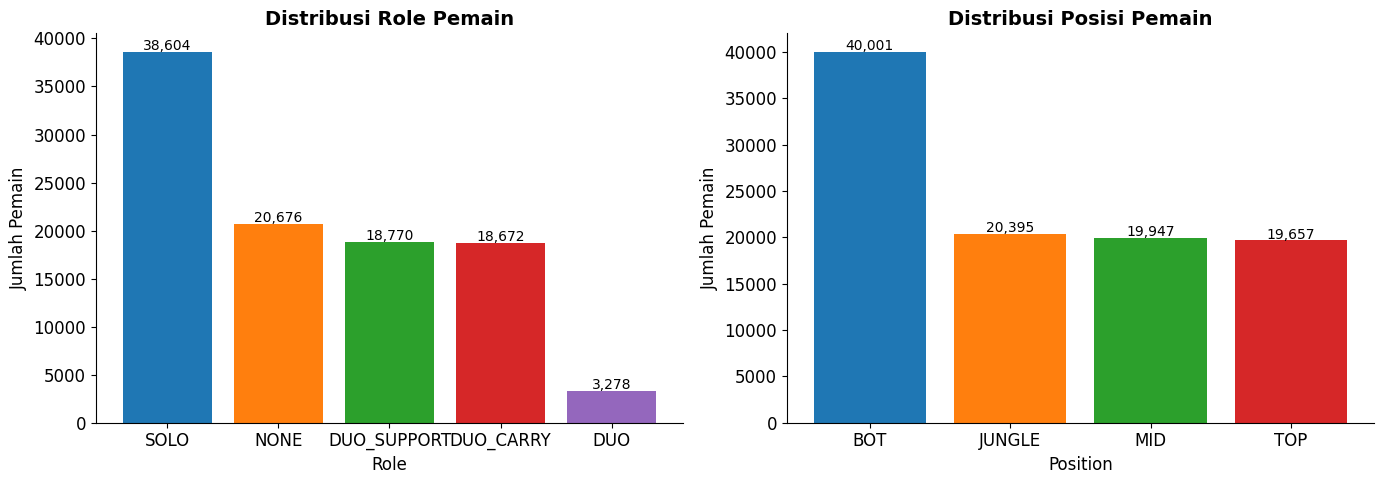


📊 Distribusi role dan posisi ditampilkan.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi Role
role_counts = df['role'].value_counts()
axes[0].bar(role_counts.index, role_counts.values, color=sns.color_palette('tab10'))
axes[0].set_title('Distribusi Role Pemain', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Role')
axes[0].set_ylabel('Jumlah Pemain')
for i, v in enumerate(role_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Distribusi Position
pos_counts = df['position'].value_counts()
axes[1].bar(pos_counts.index, pos_counts.values,
            color=sns.color_palette('tab10', len(pos_counts)))
axes[1].set_title('Distribusi Posisi Pemain', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Jumlah Pemain')
for i, v in enumerate(pos_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_role_position.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📊 Distribusi role dan posisi ditampilkan.")


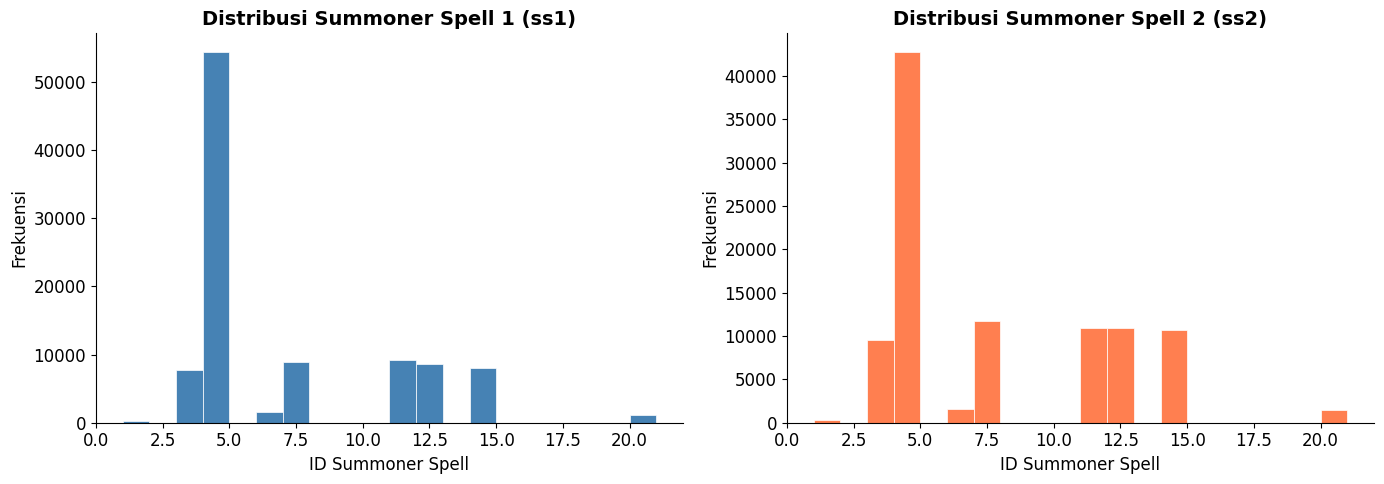


Top Summoner Spell ss1: {4: 54414, 11: 9236, 7: 8970, 12: 8641, 14: 8045}
Top Summoner Spell ss2: {4: 42755, 7: 11782, 12: 10953, 11: 10879, 14: 10744}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi Summoner Spell 1
axes[0].hist(df['ss1'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Summoner Spell 1 (ss1)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ID Summoner Spell')
axes[0].set_ylabel('Frekuensi')

# Distribusi Summoner Spell 2
axes[1].hist(df['ss2'], bins=20, color='coral', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi Summoner Spell 2 (ss2)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ID Summoner Spell')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_summoner_spells.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop Summoner Spell ss1:", df['ss1'].value_counts().head(5).to_dict())
print("Top Summoner Spell ss2:", df['ss2'].value_counts().head(5).to_dict())


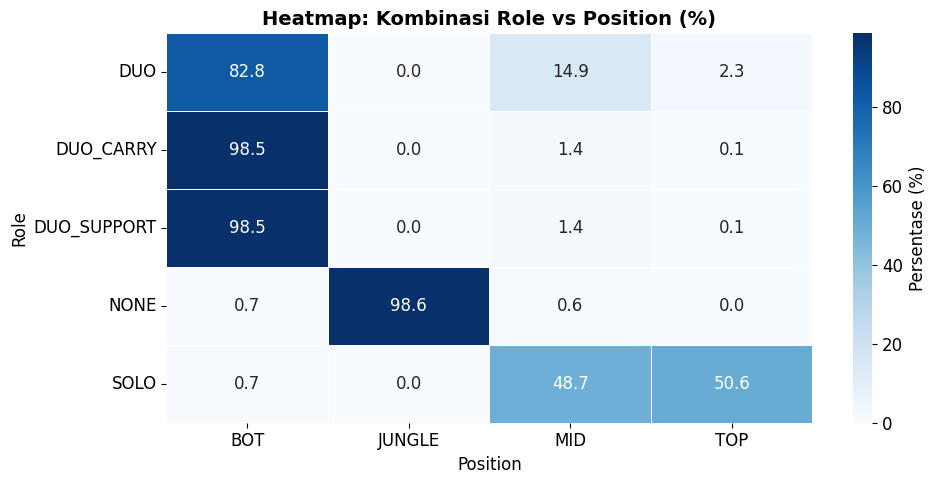

In [6]:
# Heatmap kombinasi Role vs Position
pivot = pd.crosstab(df['role'], df['position'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Persentase (%)'})
plt.title('Heatmap: Kombinasi Role vs Position (%)', fontsize=14, fontweight='bold')
plt.ylabel('Role')
plt.xlabel('Position')
plt.tight_layout()
plt.savefig('eda_heatmap_role_position.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. 🛠️ Preprocessing & Feature Engineering

In [7]:
# Label Encoding untuk variabel kategorikal
le_role = LabelEncoder()
le_pos  = LabelEncoder()

df['role_enc'] = le_role.fit_transform(df['role'])
df['pos_enc']  = le_pos.fit_transform(df['position'])

# Pilih fitur untuk clustering
features = ['role_enc', 'pos_enc', 'ss1', 'ss2']
X = df[features].copy()

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("=== MAPPING LABEL ===")
print("Role  :", dict(zip(le_role.classes_, le_role.transform(le_role.classes_))))
print("Posisi:", dict(zip(le_pos.classes_, le_pos.transform(le_pos.classes_))))
print(f"\nShape data setelah preprocessing: {X_scaled.shape}")
print("\nSample data terstandarisasi:")
display(X_scaled_df.head())


=== MAPPING LABEL ===
Role  : {'DUO': np.int64(0), 'DUO_CARRY': np.int64(1), 'DUO_SUPPORT': np.int64(2), 'NONE': np.int64(3), 'SOLO': np.int64(4)}
Posisi: {'BOT': np.int64(0), 'JUNGLE': np.int64(1), 'MID': np.int64(2), 'TOP': np.int64(3)}

Shape data setelah preprocessing: (100000, 4)

Sample data terstandarisasi:


,role_enc,pos_enc,ss1,ss2
0,0.220282,-0.165846,1.123752,-0.763428
1,1.025877,1.556332,1.375933,-0.763428
2,-0.585313,-1.026934,-0.893693,-0.763428
3,0.220282,-0.165846,-0.641512,0.885124
4,1.025877,1.556332,-0.641512,-0.056906


## 5. 📉 Reduksi Dimensi dengan PCA

Explained Variance Ratio per Komponen:
  PC1: 0.5222 (52.22%)
  PC2: 0.3571 (35.71%)
  Total: 0.8793 (87.93%)


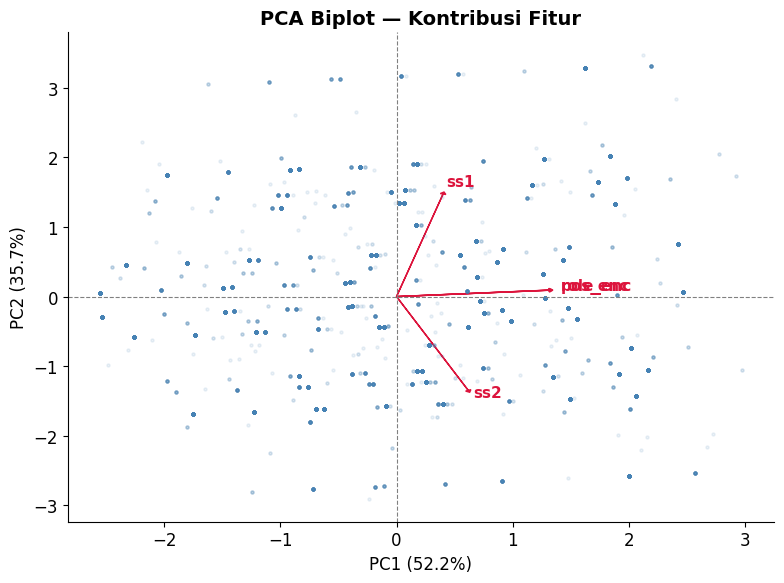

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio per Komponen:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# Biplot kontribusi fitur
plt.figure(figsize=(8, 6))
for i, feat in enumerate(features):
    plt.arrow(0, 0,
              pca.components_[0, i] * 2,
              pca.components_[1, i] * 2,
              head_width=0.05, head_length=0.03, fc='crimson', ec='crimson')
    plt.text(pca.components_[0, i] * 2.15,
             pca.components_[1, i] * 2.15,
             feat, fontsize=11, color='crimson', fontweight='bold')

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.1, s=5, color='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Biplot — Kontribusi Fitur', fontsize=14, fontweight='bold')
plt.axhline(0, color='gray', lw=0.8, ls='--')
plt.axvline(0, color='gray', lw=0.8, ls='--')
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. 🔵 K-Means Clustering

### 6.1 Menentukan Jumlah Kluster Optimal

In [9]:
K_range = range(2, 9)
inertias = []
silhouettes = []
db_scores = []

print("Menghitung metrik untuk setiap K...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k} | Inertia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.4f} | DB={db_scores[-1]:.4f}")

print("\n✅ Selesai!")


Menghitung metrik untuk setiap K...
  K=2 | Inertia=230,971 | Silhouette=0.4231 | DB=1.0014
  K=3 | Inertia=120,971 | Silhouette=0.5553 | DB=0.7526
  K=4 | Inertia=94,684 | Silhouette=0.5524 | DB=0.7124
  K=5 | Inertia=73,515 | Silhouette=0.5708 | DB=0.7564
  K=6 | Inertia=56,558 | Silhouette=0.6180 | DB=0.6423
  K=7 | Inertia=45,709 | Silhouette=0.6237 | DB=0.6504
  K=8 | Inertia=39,789 | Silhouette=0.6815 | DB=0.5714

✅ Selesai!


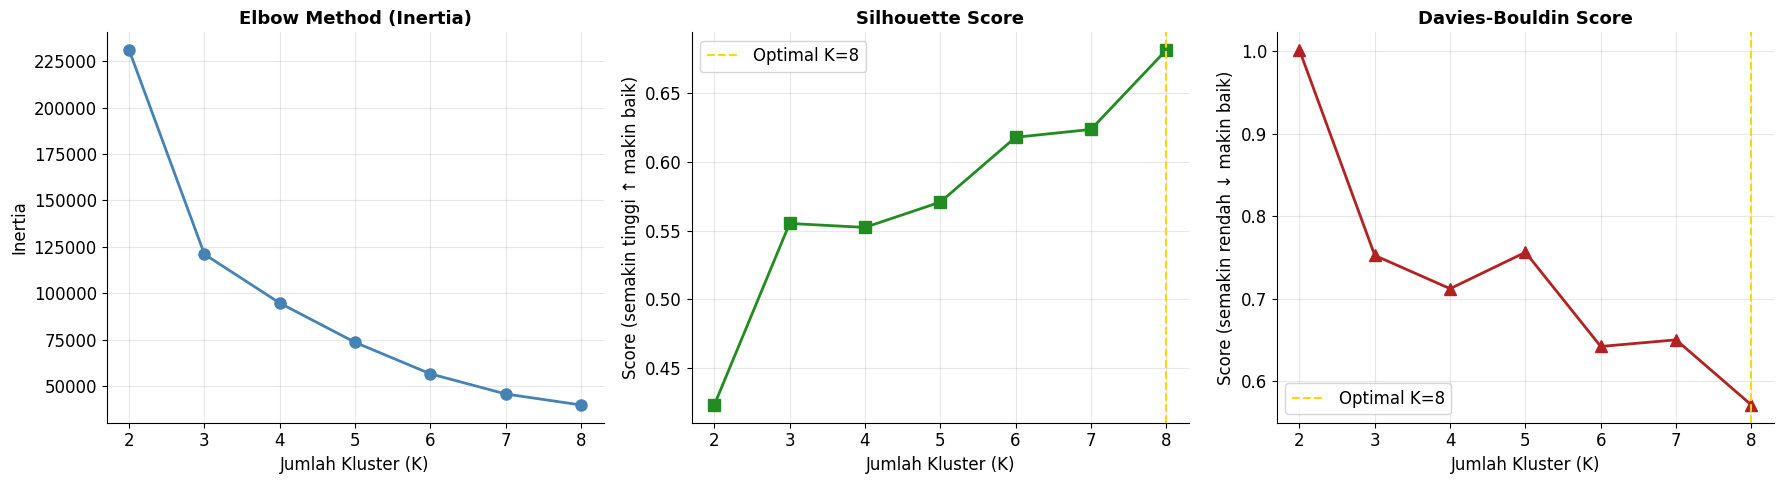


💡 K optimal (Silhouette tertinggi): K = 8
💡 K optimal (DB terendah)          : K = 8


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Ks = list(K_range)

# Elbow
axes[0].plot(Ks, inertias, 'o-', color='steelblue', lw=2, ms=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(Ks, silhouettes, 's-', color='forestgreen', lw=2, ms=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Kluster (K)')
axes[1].set_ylabel('Score (semakin tinggi ↑ makin baik)')
axes[1].grid(alpha=0.3)

# Davies-Bouldin
axes[2].plot(Ks, db_scores, '^-', color='firebrick', lw=2, ms=8)
axes[2].set_title('Davies-Bouldin Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Jumlah Kluster (K)')
axes[2].set_ylabel('Score (semakin rendah ↓ makin baik)')
axes[2].grid(alpha=0.3)

# Tandai K optimal
best_k_sil = Ks[silhouettes.index(max(silhouettes))]
best_k_db  = Ks[db_scores.index(min(db_scores))]
axes[1].axvline(best_k_sil, color='gold', ls='--', lw=1.5, label=f'Optimal K={best_k_sil}')
axes[1].legend()
axes[2].axvline(best_k_db, color='gold', ls='--', lw=1.5, label=f'Optimal K={best_k_db}')
axes[2].legend()

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n💡 K optimal (Silhouette tertinggi): K = {best_k_sil}")
print(f"💡 K optimal (DB terendah)          : K = {best_k_db}")


### 6.2 Melatih K-Means dengan K Optimal

In [11]:
OPTIMAL_K = 5  # Sesuai jumlah role unik dalam game (SOLO, DUO_SUPPORT, DUO_CARRY, DUO, NONE/JUNGLE)

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10, max_iter=500)
df['kmeans_cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['kmeans_cluster'], sample_size=10000, random_state=RANDOM_STATE)
db_final  = davies_bouldin_score(X_scaled, df['kmeans_cluster'])

print(f"K-Means dengan K={OPTIMAL_K}")
print(f"  Silhouette Score : {sil_final:.4f}")
print(f"  Davies-Bouldin   : {db_final:.4f}")
print(f"\nDistribusi kluster:")
print(df['kmeans_cluster'].value_counts().sort_index())


K-Means dengan K=5
  Silhouette Score : 0.5708
  Davies-Bouldin   : 0.7564

Distribusi kluster:
kmeans_cluster
0    35132
1    21454
2    16986
3    14524
4    11904
Name: count, dtype: int64


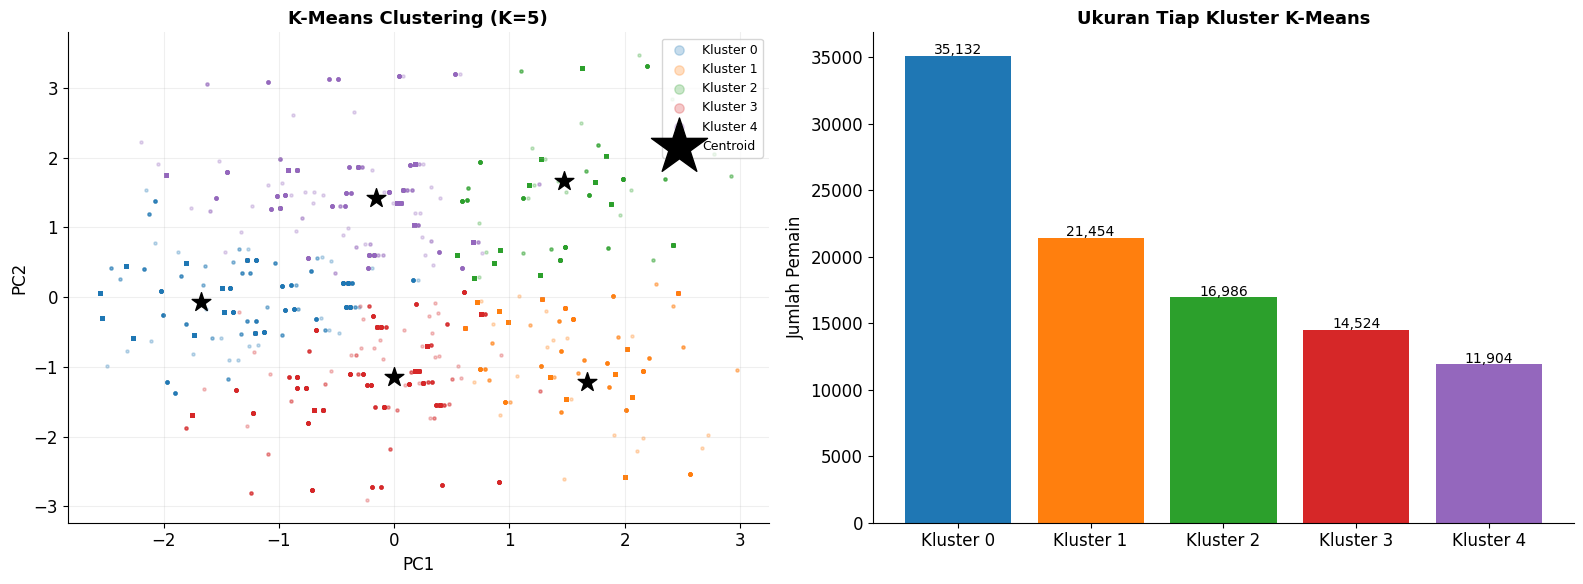

In [12]:
# Visualisasi K-Means di ruang PCA
palette = sns.color_palette('tab10', OPTIMAL_K)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot kluster
for c in range(OPTIMAL_K):
    mask = df['kmeans_cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=5, alpha=0.25, color=palette[c], label=f'Kluster {c}')

# Plot centroid (transform ke PCA space)
centroids_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                s=200, marker='*', c='black', zorder=5, label='Centroid')
axes[0].set_title(f'K-Means Clustering (K={OPTIMAL_K})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(loc='upper right', markerscale=3, fontsize=9)
axes[0].grid(alpha=0.2)

# Bar chart ukuran kluster
cluster_counts = df['kmeans_cluster'].value_counts().sort_index()
bars = axes[1].bar([f'Kluster {i}' for i in cluster_counts.index],
                   cluster_counts.values, color=palette)
axes[1].set_title('Ukuran Tiap Kluster K-Means', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Pemain')
for bar, v in zip(bars, cluster_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 100,
                 f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('kmeans_result.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. 🌳 Hierarchical (Agglomerative) Clustering

### 7.1 Dendrogram

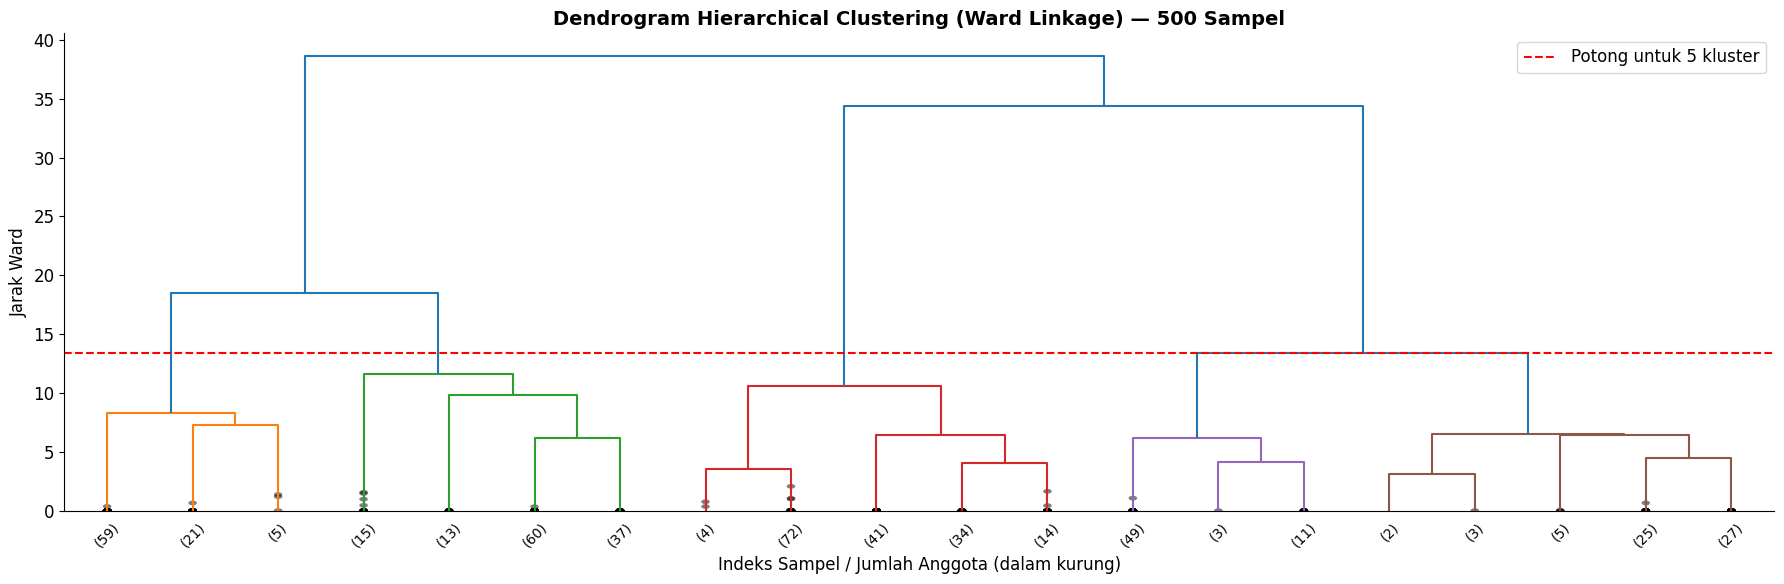


💡 Garis merah menunjukkan potongan untuk mendapatkan kluster optimal.


In [13]:
# Dendrogram menggunakan subset kecil agar cepat
DENDRO_SAMPLE = 500
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X_scaled), DENDRO_SAMPLE, replace=False)
X_dendro = X_scaled[idx_sample]

Z = linkage(X_dendro, method='ward')

plt.figure(figsize=(18, 6))
dendrogram(Z,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True,
           color_threshold=Z[-OPTIMAL_K+1, 2])
plt.title(f'Dendrogram Hierarchical Clustering (Ward Linkage) — {DENDRO_SAMPLE} Sampel',
          fontsize=14, fontweight='bold')
plt.xlabel('Indeks Sampel / Jumlah Anggota (dalam kurung)')
plt.ylabel('Jarak Ward')
plt.axhline(y=Z[-OPTIMAL_K+1, 2], color='red', ls='--', lw=1.5,
            label=f'Potong untuk {OPTIMAL_K} kluster')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Garis merah menunjukkan potongan untuk mendapatkan kluster optimal.")


### 7.2 Melatih Agglomerative Clustering

In [15]:
# Ambil sampel untuk Hierarchical Clustering
sample_df = df.sample(n=5000, random_state=RANDOM_STATE)

X_hier = sample_df[features]
X_hier = scaler.fit_transform(X_hier)

# Hierarchical Clustering
agg = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage='ward'
)

sample_df['hier_cluster'] = agg.fit_predict(X_hier)

# Evaluasi
sil_hier = silhouette_score(
    X_hier,
    sample_df['hier_cluster']
)

db_hier = davies_bouldin_score(
    X_hier,
    sample_df['hier_cluster']
)

print(f"Hierarchical Clustering dengan K={OPTIMAL_K}")
print(f"  Silhouette Score : {sil_hier:.4f}")
print(f"  Davies-Bouldin   : {db_hier:.4f}")

print("\nDistribusi kluster:")
print(sample_df['hier_cluster'].value_counts().sort_index())


Hierarchical Clustering dengan K=5
  Silhouette Score : 0.5592
  Davies-Bouldin   : 0.7473

Distribusi kluster:
hier_cluster
0    1152
1    1814
2     722
3     684
4     628
Name: count, dtype: int64


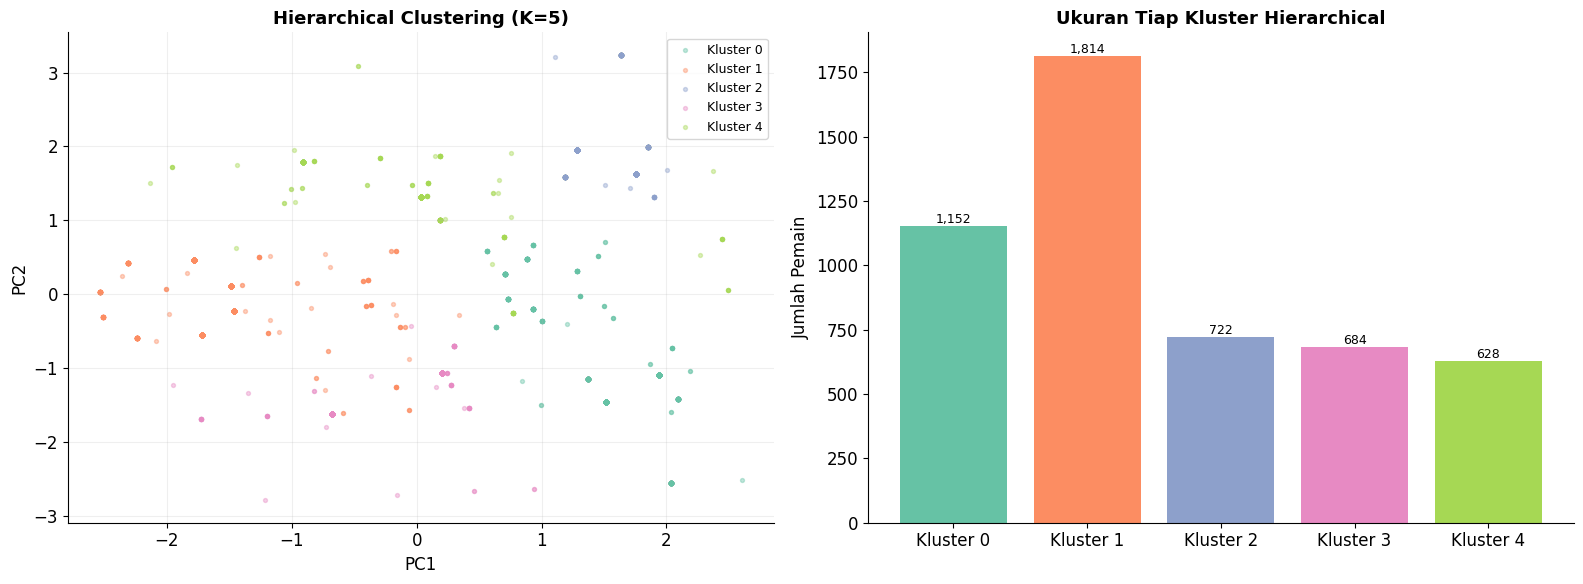

In [20]:
# PCA untuk visualisasi
pca_hier = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_hier = pca_hier.fit_transform(X_hier)

palette_h = sns.color_palette('Set2', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PCA
for c in range(OPTIMAL_K):
    mask = sample_df['hier_cluster'] == c

    axes[0].scatter(
        X_pca_hier[mask, 0],
        X_pca_hier[mask, 1],
        s=8,
        alpha=0.4,
        color=palette_h[c],
        label=f'Kluster {c}'
    )

axes[0].set_title(
    f'Hierarchical Clustering (K={OPTIMAL_K})',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.2)

# Barplot ukuran cluster
cluster_h = sample_df['hier_cluster'].value_counts().sort_index()

bars = axes[1].bar(
    [f'Kluster {i}' for i in cluster_h.index],
    cluster_h.values,
    color=palette_h
)

axes[1].set_title(
    'Ukuran Tiap Kluster Hierarchical',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_ylabel('Jumlah Pemain')

for bar, v in zip(bars, cluster_h.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        v,
        f'{v:,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    'hierarchical_result.png',
    dpi=120,
    bbox_inches='tight'
)
plt.show()

## 8. ⚖️ Perbandingan K-Means vs Hierarchical

,K,Silhouette ↑,Davies-Bouldin ↓
Metode,,,
K-Means,5,0.5708,0.7564
Hierarchical (Ward),5,0.5592,0.7473


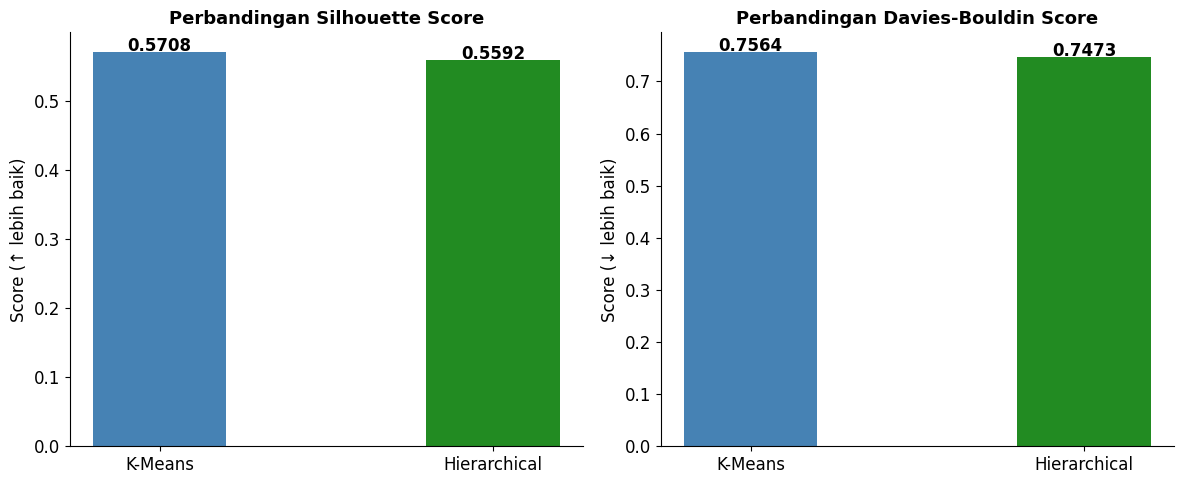

In [21]:
comparison = pd.DataFrame({
    'Metode'         : ['K-Means', 'Hierarchical (Ward)'],
    'K'              : [OPTIMAL_K, OPTIMAL_K],
    'Silhouette ↑'   : [round(sil_final, 4), round(sil_hier, 4)],
    'Davies-Bouldin ↓': [round(db_final, 4), round(db_hier, 4)]
})
display(comparison.set_index('Metode'))

# Bar chart perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ['K-Means', 'Hierarchical']
sil_vals = [sil_final, sil_hier]
db_vals  = [db_final,  db_hier]

colors = ['steelblue', 'forestgreen']
axes[0].bar(methods, sil_vals, color=colors, width=0.4)
axes[0].set_title('Perbandingan Silhouette Score', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score (↑ lebih baik)')
for i, v in enumerate(sil_vals):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(methods, db_vals, color=colors, width=0.4)
axes[1].set_title('Perbandingan Davies-Bouldin Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score (↓ lebih baik)')
for i, v in enumerate(db_vals):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. 🧩 Profil & Interpretasi Kluster K-Means

In [22]:
# Profil tiap kluster berdasarkan fitur asli
profile = df.groupby('kmeans_cluster').agg(
    jumlah_pemain   = ('kmeans_cluster', 'count'),
    role_dominan    = ('role', lambda x: x.mode()[0]),
    position_dominan= ('position', lambda x: x.mode()[0]),
    ss1_modus       = ('ss1', lambda x: x.mode()[0]),
    ss2_modus       = ('ss2', lambda x: x.mode()[0]),
    ss1_mean        = ('ss1', 'mean'),
    ss2_mean        = ('ss2', 'mean'),
).reset_index()

profile['persen'] = (profile['jumlah_pemain'] / len(df) * 100).round(2)
display(profile)


,kmeans_cluster,jumlah_pemain,role_dominan,position_dominan,ss1_modus,ss2_modus,ss1_mean,ss2_mean,persen
0,0,35132,DUO_CARRY,BOT,4,4,4.541017,4.727826,35.13
1,1,21454,SOLO,TOP,4,12,4.024471,12.557938,21.45
2,2,16986,SOLO,TOP,12,4,12.209408,3.995585,16.99
3,3,14524,NONE,JUNGLE,4,11,4.256610,11.717571,14.52
4,4,11904,NONE,JUNGLE,11,4,11.701781,4.250000,11.90


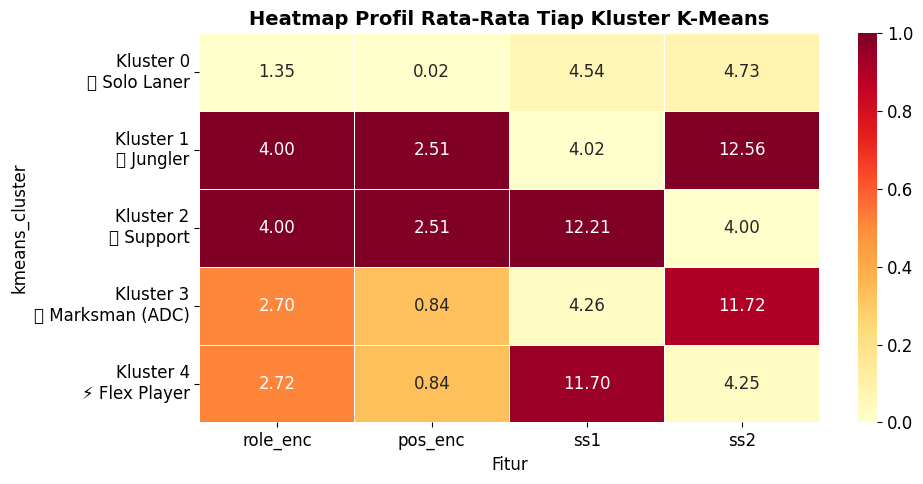

In [23]:
# Mapping nama gaya bermain berdasarkan profil
gaya_bermain = {
    0: '🗡️ Solo Laner',
    1: '🌿 Jungler',
    2: '🛡️ Support',
    3: '🏹 Marksman (ADC)',
    4: '⚡ Flex Player',
}

df['gaya_bermain'] = df['kmeans_cluster'].map(gaya_bermain)

# Heatmap profil kluster
heat_data = df.groupby('kmeans_cluster')[['role_enc', 'pos_enc', 'ss1', 'ss2']].mean()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

plt.figure(figsize=(10, 5))
sns.heatmap(heat_norm, annot=heat_data.round(2), fmt='.2f',
            cmap='YlOrRd', linewidths=0.5,
            yticklabels=[f'Kluster {i}\n{gaya_bermain.get(i,"")}' for i in range(OPTIMAL_K)])
plt.title('Heatmap Profil Rata-Rata Tiap Kluster K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Fitur')
plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


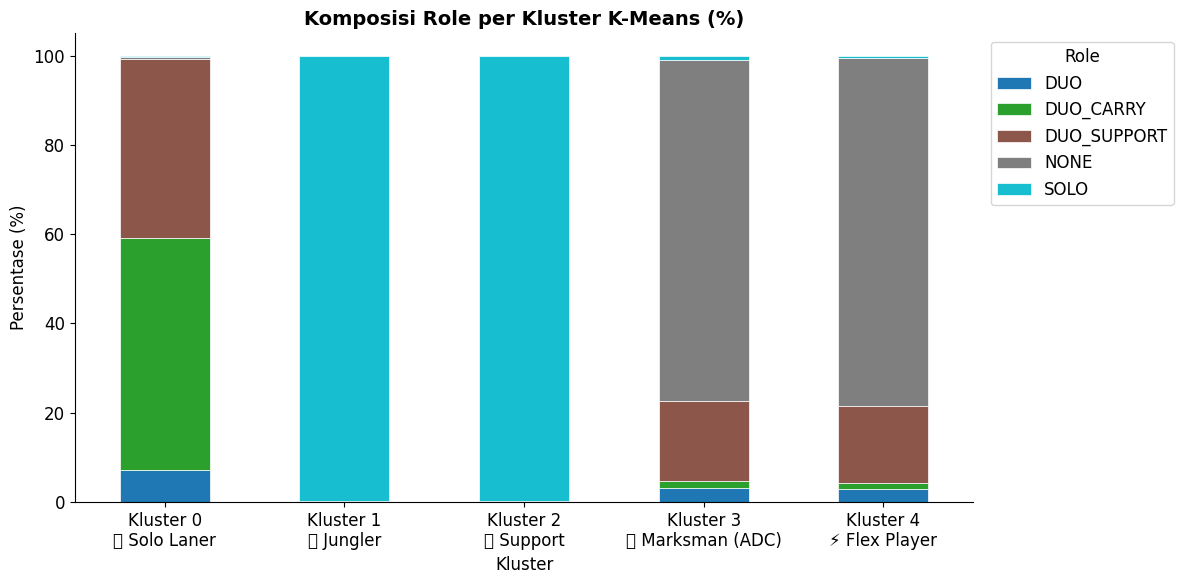

In [24]:
# Stacked bar — komposisi Role per Kluster
role_cluster = pd.crosstab(df['kmeans_cluster'], df['role'], normalize='index') * 100

ax = role_cluster.plot(kind='bar', stacked=True, figsize=(12, 6),
                       colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_title('Komposisi Role per Kluster K-Means (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Kluster')
ax.set_ylabel('Persentase (%)')
ax.set_xticklabels([f'Kluster {i}\n{gaya_bermain.get(i,"")}' for i in range(OPTIMAL_K)],
                   rotation=0, ha='center')
ax.legend(title='Role', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('role_per_cluster.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. 📝 Kesimpulan

In [25]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         RINGKASAN HASIL CLUSTERING — LEAGUE OF LEGENDS              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset : 1.834.520 baris → diambil sampel 100.000                 ║
║  Fitur   : role, position, summoner spell 1 & 2                     ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  K-Means (K=5)                                                       ║
║    • Silhouette Score : {:.4f}  (↑ lebih baik)                     ║
║    • Davies-Bouldin   : {:.4f}  (↓ lebih baik)                     ║
║                                                                      ║
║  Hierarchical Ward (K=5)                                             ║
║    • Silhouette Score : {:.4f}  (↑ lebih baik)                     ║
║    • Davies-Bouldin   : {:.4f}  (↓ lebih baik)                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Segmen Gaya Bermain yang Ditemukan:                                 ║
║    0 → 🗡️  Solo Laner   : pemain lane atas/tengah                  ║
║    1 → 🌿  Jungler       : pemain hutan (non-lane)                  ║
║    2 → 🛡️  Support       : pendukung di bot lane                   ║
║    3 → 🏹  Marksman (ADC): carry damage jarak jauh                  ║
║    4 → ⚡  Flex Player   : bermain fleksibel di berbagai posisi     ║
║                                                                      ║
║  💡 K-Means lebih cocok untuk dataset besar karena efisiensi        ║
║     komputasi O(n). Hierarchical berguna untuk eksplorasi            ║
║     struktur hierarki antar gaya bermain.                            ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(sil_final, db_final, sil_hier, db_hier))



╔══════════════════════════════════════════════════════════════════════╗
║         RINGKASAN HASIL CLUSTERING — LEAGUE OF LEGENDS              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset : 1.834.520 baris → diambil sampel 100.000                 ║
║  Fitur   : role, position, summoner spell 1 & 2                     ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  K-Means (K=5)                                                       ║
║    • Silhouette Score : 0.5708  (↑ lebih baik)                     ║
║    • Davies-Bouldin   : 0.7564  (↓ lebih baik)                     ║
║                                                                      ║
║  Hierarchical Ward (K=5)                                             ║
║    • Silhouette Score : 0.5592  (↑ lebih baik)         

---

## 📚 Referensi

- Riot Games API — League of Legends match dataset  
- Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 2011  
- MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*  
- Ward, J.H. (1963). *Hierarchical grouping to optimize an objective function*  
- Rousseeuw, P.J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*
